# Swift Project - Exploratory Data Analysis
This notebook provides key visualizations and complex analyses for the Swift multi-lingual dataset.
Run the cells below to generate the plots for your presentation.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Adjust plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load the Dataset
We'll load the English training data for EDA since labels are consistent across languages.

In [14]:
data_path = '../../datasets/english/train_labeled.csv'
df = pd.read_csv(data_path)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (9998, 6)


,id,text_en,text,category,sentiment,priority
0,0,I am still waiting on my card?,I am still waiting on my card?,card_arrival,Neutral,Low
1,1,What can I do if my card still hasn't arrived ...,What can I do if my card still hasn't arrived ...,card_arrival,Neutral,Low
2,2,I have been waiting over a week. Is the card s...,I have been waiting over a week. Is the card s...,card_arrival,Neutral,Low
3,3,Can I track my card while it is in the process...,Can I track my card while it is in the process...,card_arrival,Neutral,Low
4,4,"How do I know if I will get my card, or if it ...","How do I know if I will get my card, or if it ...",card_arrival,Neutral,Low


## 2. Intent Category Distribution (All Intents in 2 Parts)
Displaying all 77 intent categories split into two charts.

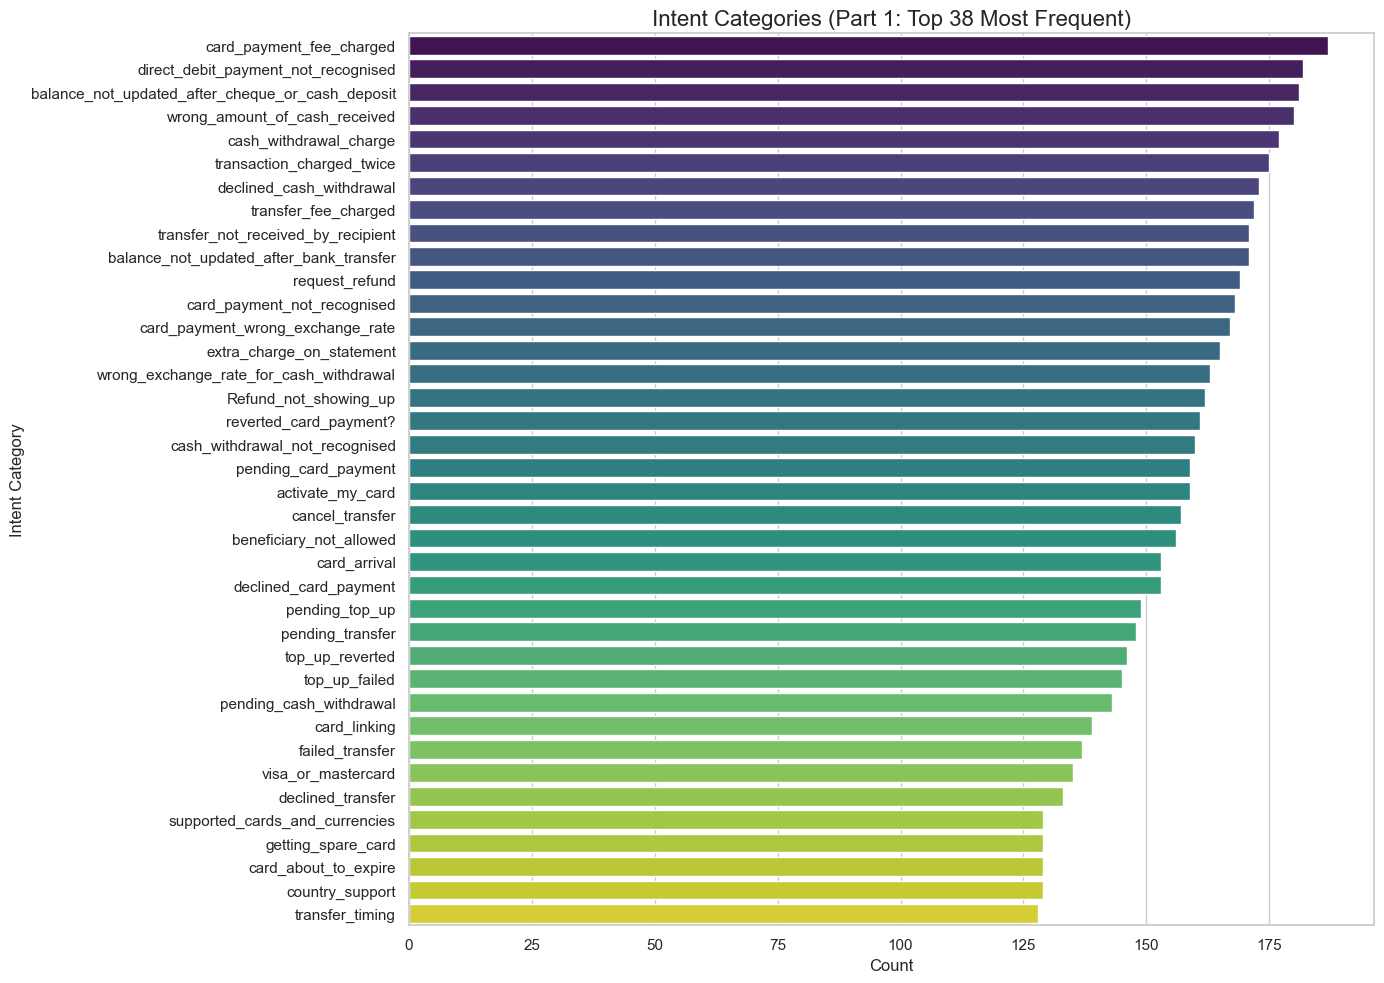

In [15]:
intent_counts = df['category'].value_counts()
half = len(intent_counts) // 2

plt.figure(figsize=(14, 10))
part1 = intent_counts.iloc[:half]
sns.barplot(x=part1.values, y=part1.index, palette='viridis')
plt.title(f'Intent Categories (Part 1: Top {half} Most Frequent)', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Intent Category', fontsize=12)
plt.tight_layout()
plt.show()

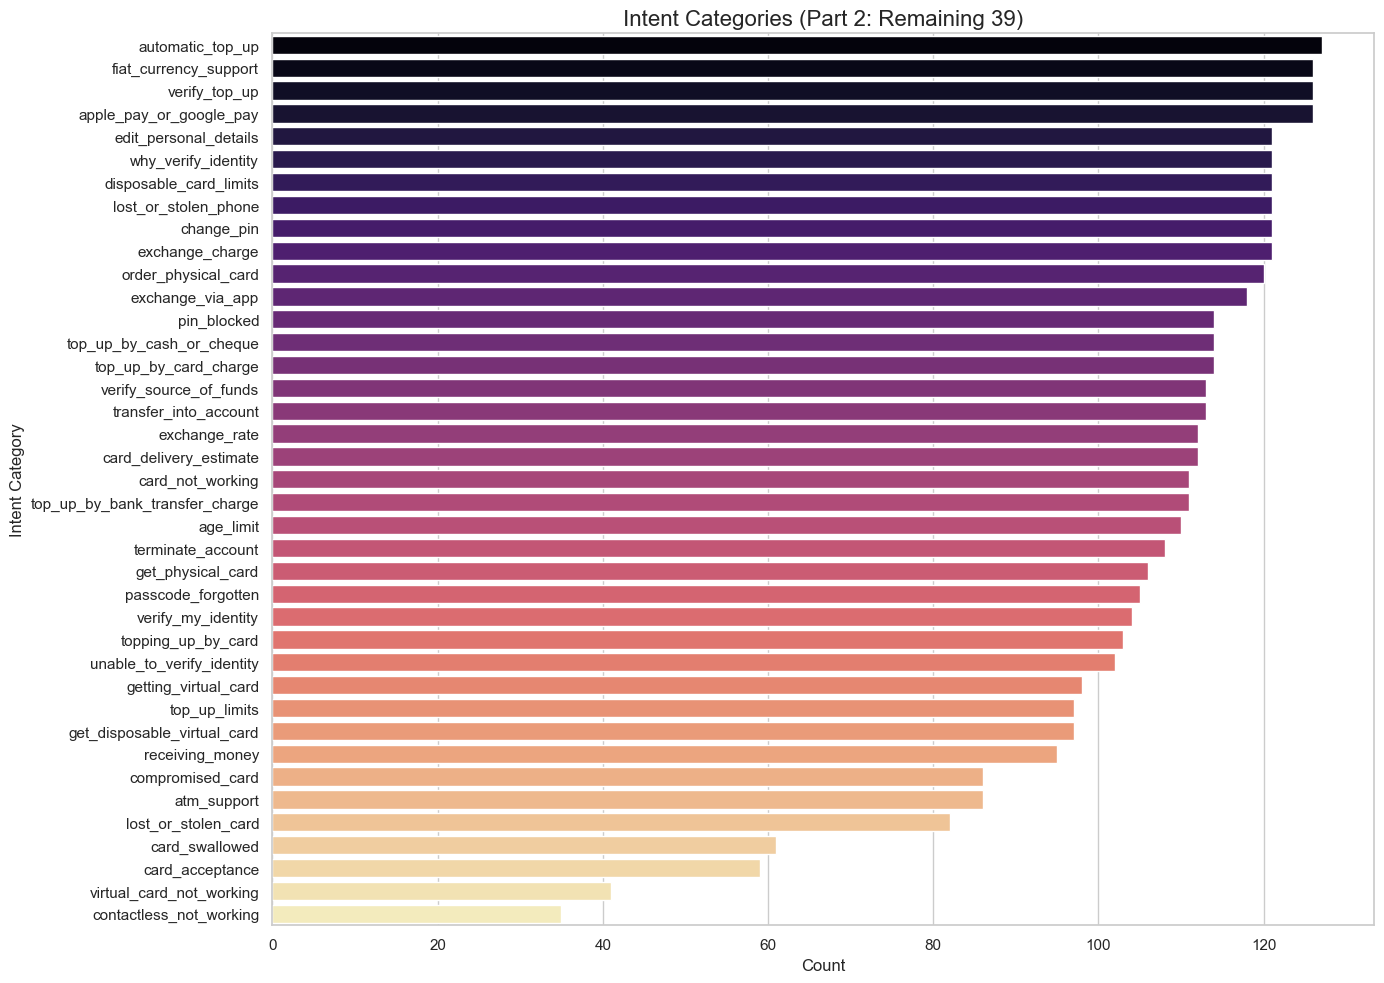

In [16]:
plt.figure(figsize=(14, 10))
part2 = intent_counts.iloc[half:]
sns.barplot(x=part2.values, y=part2.index, palette='magma')
plt.title(f'Intent Categories (Part 2: Remaining {len(intent_counts) - half})', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Intent Category', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Basic Class Distributions (Sentiment & Priority)

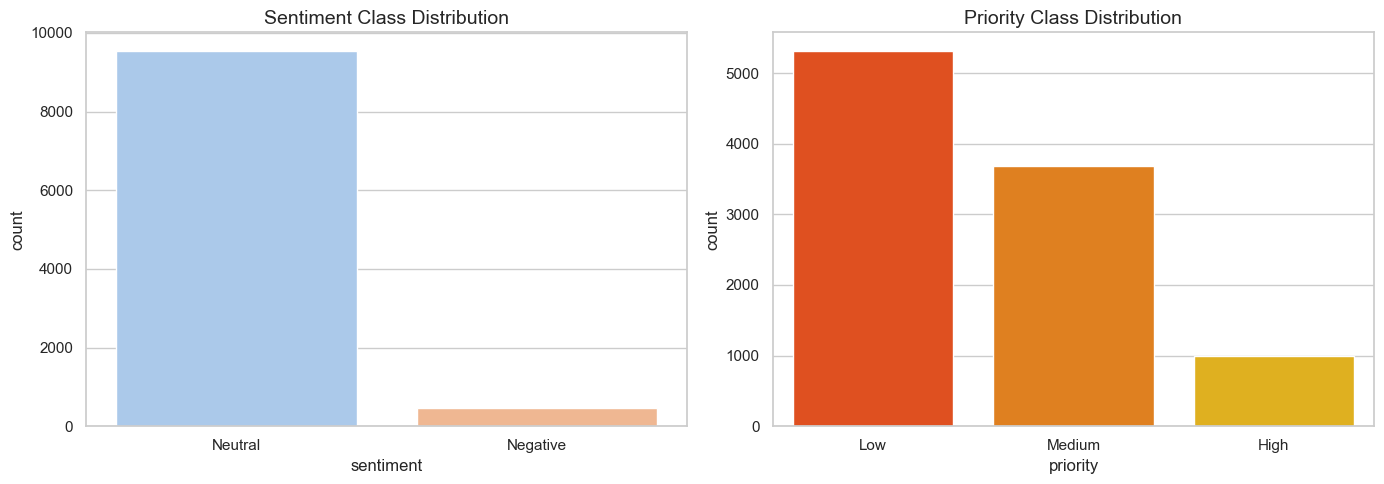

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='sentiment', palette='pastel', ax=axes[0])
axes[0].set_title('Sentiment Class Distribution', fontsize=14)

order = ['Low', 'Medium', 'High']
sns.countplot(data=df, x='priority', order=order, palette='autumn', ax=axes[1])
axes[1].set_title('Priority Class Distribution', fontsize=14)

plt.tight_layout()
plt.show()

## 4. Complex Analysis: Priority vs Sentiment Correlation
Are high priority tickets more likely to contain negative sentiment? We use a normalized heatmap to show the cross-tabulation.

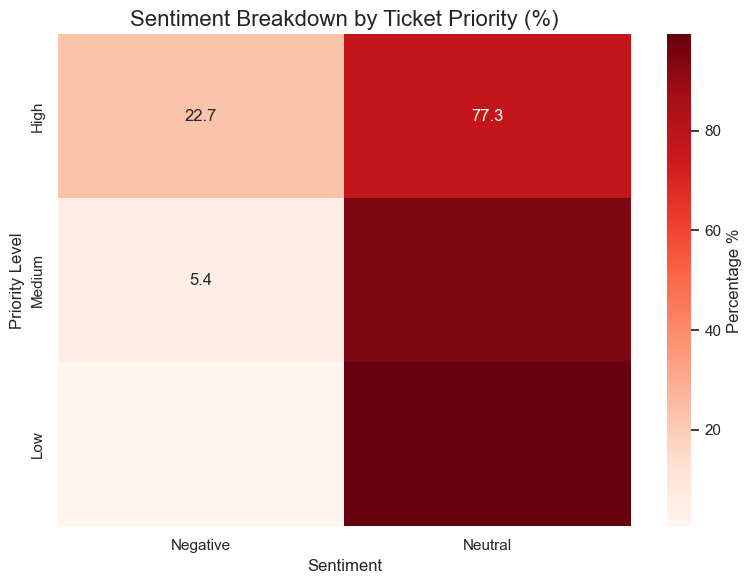

In [18]:
plt.figure(figsize=(8, 6))
# Calculate percentage of sentiment per priority level
ct = pd.crosstab(df['priority'], df['sentiment'], normalize='index') * 100
# Reorder for logical progression
ct = ct.reindex(['High', 'Medium', 'Low'])

sns.heatmap(ct, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label': 'Percentage %'})
plt.title('Sentiment Breakdown by Ticket Priority (%)', fontsize=16)
plt.ylabel('Priority Level', fontsize=12)
plt.xlabel('Sentiment', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Complex Analysis: Intents Driving Negative Sentiment
Which specific intent categories are most associated with a negative user experience?

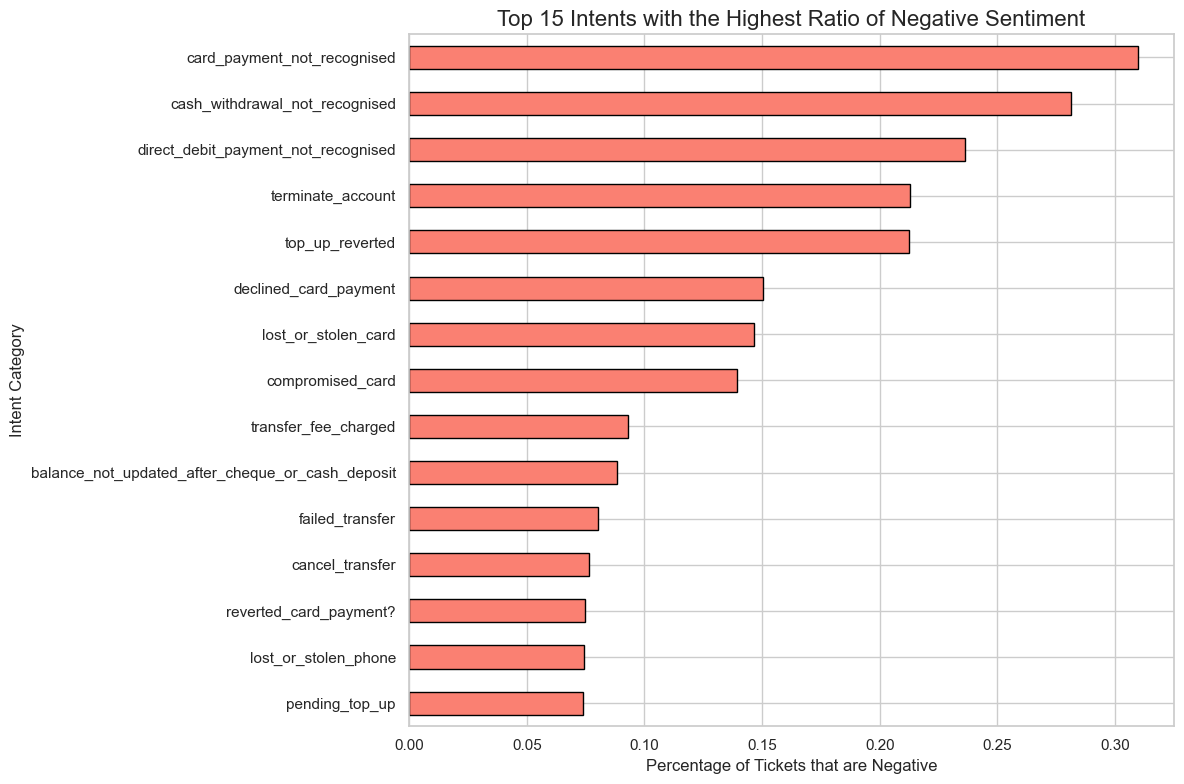

In [19]:
plt.figure(figsize=(12, 8))

# Calculate % of Negative sentiment per category
sentiment_pct = df.groupby('category')['sentiment'].value_counts(normalize=True).unstack().fillna(0)
if 'Negative' in sentiment_pct.columns:
    top_negative_intents = sentiment_pct['Negative'].sort_values(ascending=False).head(15)
    
    top_negative_intents.plot(kind='barh', color='salmon', edgecolor='black')
    plt.title('Top 15 Intents with the Highest Ratio of Negative Sentiment', fontsize=16)
    plt.xlabel('Percentage of Tickets that are Negative', fontsize=12)
    plt.ylabel('Intent Category', fontsize=12)
    plt.gca().invert_yaxis()  # Highest at the top
    plt.tight_layout()
    plt.show()
else:
    print("No negative sentiment found.")

## 6. Complex Analysis: Text Length by Priority
Do users write longer tickets when the issue is high priority? A boxplot gives us the statistical spread.

<Figure size 1000x600 with 0 Axes>

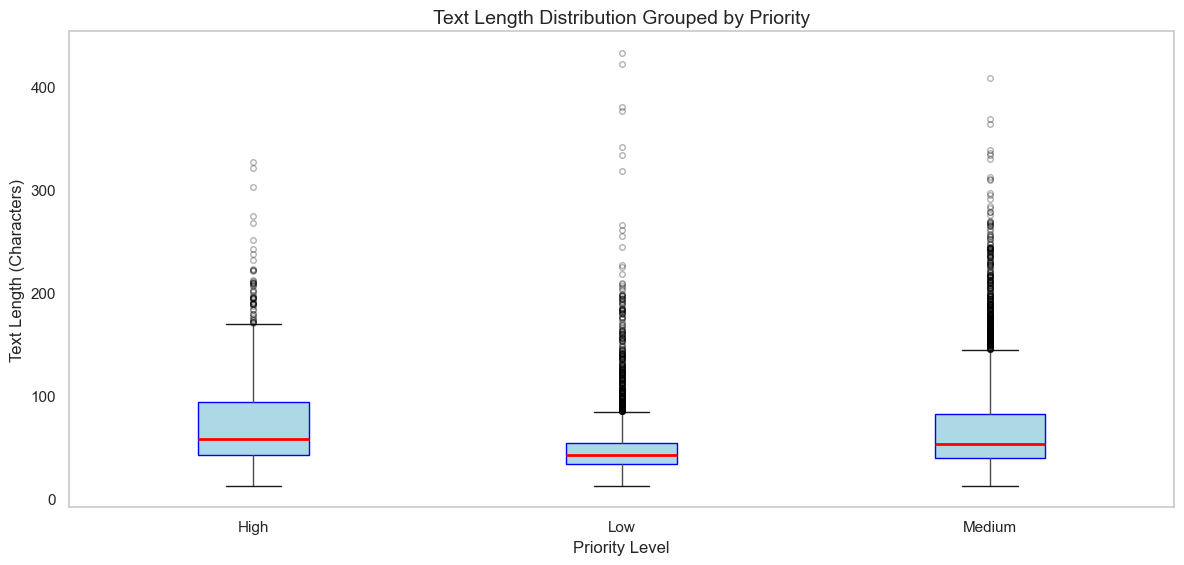

In [20]:
df['text_length'] = df['text'].apply(len)

plt.figure(figsize=(10, 6))
# Standard pandas boxplot mapped to matplotlib to avoid seaborn version bugs
ax = df.boxplot(column='text_length', by='priority', grid=False, 
                patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', color='gray', alpha=0.3, markersize=4))

plt.title('Text Length Distribution Grouped by Priority', fontsize=14)
plt.suptitle('')  # Remove automatic pandas title
plt.xlabel('Priority Level', fontsize=12)
plt.ylabel('Text Length (Characters)', fontsize=12)
plt.tight_layout()
plt.show()